In [1]:
'''选取贵州茅台作为针对的股票，其中2015-2021年的数据用来训练'''
import pandas as pd
import numpy as np


# df1=get_all_securities()
# df1[df1.display_name=='贵州茅台']


In [2]:
import akshare as ak

# 仅需这一行，即可获取贵州茅台当天的实时行情
stock_df = ak.stock_zh_a_spot_em()
print(stock_df[stock_df['代码'] == '600519'])

  0%|          | 0/58 [00:00<?, ?it/s]

        序号      代码    名称      最新价   涨跌幅    涨跌额      成交量           成交额    振幅  \
1938  1939  600519  贵州茅台  1361.73  0.79  10.67  11515.0  1.562899e+09  0.72   

           最高  ...    量比   换手率  市盈率-动态   市净率           总市值          流通市值   涨速  \
1938  1361.76  ...  1.34  0.09   19.79  7.51  1.705254e+12  1.705254e+12  0.1   

      5分钟涨跌  60日涨跌幅  年初至今涨跌幅  
1938   0.12   -4.17    -1.12  

[1 rows x 23 columns]


In [39]:
#获取原始数据
# 1. 修改股票代码：AkShare 只需要数字代码
symbol = "600519" 

# 2. 获取训练数据
# 注意：AkShare 的日期格式为 'YYYYMMDD' (无横杠)
# adjust="qfq" 代表前复权，机器学习预测必须使用复权数据
df_train = ak.stock_zh_a_hist(
    symbol=symbol, 
    period="daily", 
    start_date="20101231", 
    end_date="20201231", 
    adjust="hfq"
)

df_train['日期'] = pd.to_datetime(df_train['日期'])

# 转换格式以对齐你后续的代码逻辑
# AkShare 返回的是中文列名，我们需要提取 '日期' 和 '收盘' 并重命名
raw_data_train = df_train[['日期', '收盘']].rename(columns={'日期': 'Date', '收盘': 'close'})
raw_data_train.set_index('Date', inplace=True)

# 3. 获取预测数据
df_predict = ak.stock_zh_a_hist(
    symbol=symbol, 
    period="daily", 
    start_date="20201231", 
    end_date="20221231", 
    adjust="hfq"
)

df_predict['日期'] = pd.to_datetime(df_predict['日期'])

raw_data_predict = df_predict[['日期', '收盘']].rename(columns={'日期': 'Date', '收盘': 'close'})
raw_data_predict.set_index('Date', inplace=True)

# 验证结果
print("训练数据条数:", len(raw_data_train))
print(raw_data_train.head())

raw_data_train

训练数据条数: 2429
             close
Date              
2010-12-31  713.74
2011-01-04  719.70
2011-01-05  703.02
2011-01-06  699.85
2011-01-07  697.88


,close
Date,
2010-12-31,713.74
2011-01-04,719.70
2011-01-05,703.02
2011-01-06,699.85
2011-01-07,697.88
...,...
2020-12-25,9583.84
2020-12-28,9799.90
2020-12-29,9769.75


In [40]:
#对原始数据打标签，label= (close_t>close_t-1)

# 1. 计算价格差值（今日收盘价 - 昨日收盘价）
price_diff1 = raw_data_train.diff()
price_diff2 = raw_data_predict.diff()

raw_data_train['label'] = (price_diff1 > 0).astype(int)
raw_data_predict['label']= (price_diff2 > 0).astype(int)
raw_data_predict

,close,label
Date,,
2020-12-31,10428.00,0
2021-01-04,10422.98,0
2021-01-05,10736.77,1
2021-01-06,10940.53,1
2021-01-07,11141.52,1
...,...,...
2022-12-26,9347.81,0
2022-12-27,9412.38,1
2022-12-28,9412.38,0


In [41]:
#剔除2014-12-31数据
raw_data_train=raw_data_train.drop(raw_data_train.index[0])
raw_data_predict=raw_data_predict.drop(raw_data_predict.index[0])

In [42]:
print(f"数据时间范围: {raw_data_train.index[0]} 到 {raw_data_train.index[-1]}")
print(f"总样本数: {len(raw_data_train)}")
raw_data_train

数据时间范围: 2011-01-04 00:00:00 到 2020-12-31 00:00:00
总样本数: 2428


,close,label
Date,,
2011-01-04,719.70,1
2011-01-05,703.02,0
2011-01-06,699.85,0
2011-01-07,697.88,0
2011-01-10,677.46,0
...,...,...
2020-12-25,9583.84,0
2020-12-28,9799.90,1
2020-12-29,9769.75,0


In [43]:
import pandas as pd
import numpy as np

def create_features(df):
    """
    创建技术指标特征
    参数:
        df: DataFrame，包含'close'列
    返回:
        添加了特征列的DataFrame
    """
    # 创建数据副本避免修改原始数据
    df_feat = df.copy()
    
    # 1. 基础特征
    # 收益率 (日收益率)
    df_feat['returns'] = df_feat['close'].pct_change()
    
    # 2. 移动平均线特征 (注意: 先计算再滞后)
    # 短期均线
    df_feat['ma_5'] = df_feat['close'].rolling(window=5).mean().shift(1)  # 滞后1天
    df_feat['ma_10'] = df_feat['close'].rolling(window=10).mean().shift(1)
    df_feat['ma_20'] = df_feat['close'].rolling(window=20).mean().shift(1)
    
    # 中长期均线
    df_feat['ma_60'] = df_feat['close'].rolling(window=60).mean().shift(1)
    
    # 3. 价格与均线关系 (趋势指标)
    df_feat['price_ma5_ratio'] = (df_feat['close'] / df_feat['ma_5'] - 1).shift(1)
    df_feat['price_ma20_ratio'] = (df_feat['close'] / df_feat['ma_20'] - 1).shift(1)
    df_feat['price_ma60_ratio'] = (df_feat['close'] / df_feat['ma_60'] - 1).shift(1)
    
    # 4. 均线交叉特征
    df_feat['ma5_ma20_diff'] = (df_feat['ma_5'] - df_feat['ma_20']).shift(1)
    df_feat['ma5_ma20_ratio'] = (df_feat['ma_5'] / df_feat['ma_20'] - 1).shift(1)
    
    # 5. 动量特征
    df_feat['momentum_5'] = (df_feat['close'] / df_feat['close'].shift(5) - 1).shift(1)
    df_feat['momentum_10'] = (df_feat['close'] / df_feat['close'].shift(10) - 1).shift(1)
    df_feat['momentum_20'] = (df_feat['close'] / df_feat['close'].shift(20) - 1).shift(1)
    
    # 6. 波动率特征
    df_feat['volatility_5'] = df_feat['returns'].rolling(window=5).std().shift(1)
    df_feat['volatility_20'] = df_feat['returns'].rolling(window=20).std().shift(1)
    
    # 7. 价格区间特征
    # 布林带 (使用20日均线)
    rolling_std = df_feat['close'].rolling(window=20).std()
    df_feat['bollinger_upper'] = (df_feat['ma_20'] + 2 * rolling_std).shift(1)
    df_feat['bollinger_lower'] = (df_feat['ma_20'] - 2 * rolling_std).shift(1)
    df_feat['bollinger_pct'] = ((df_feat['close'] - df_feat['bollinger_lower']) / 
                                (df_feat['bollinger_upper'] - df_feat['bollinger_lower'])).shift(1)
    
    # 8. 价格位置特征
    # 20日最高/最低位置
    df_feat['high_20'] = df_feat['close'].rolling(window=20).max().shift(1)
    df_feat['low_20'] = df_feat['close'].rolling(window=20).min().shift(1)
    df_feat['position_in_20day_range'] = ((df_feat['close'] - df_feat['low_20']) / 
                                         (df_feat['high_20'] - df_feat['low_20'])).shift(1)
    
    # 9. 价格变化特征
    df_feat['price_change_1'] = df_feat['close'].pct_change(1).shift(1)
    df_feat['price_change_5'] = df_feat['close'].pct_change(5).shift(1)
    
    # 10. 成交量加权特征 (如果无成交量数据，用价格变化替代)
    # 模拟成交量特征 - 实际中应使用真实成交量数据
    df_feat['volume_sim'] = df_feat['returns'].abs()  # 用收益率绝对值模拟成交量变化
    df_feat['volume_ma5'] = df_feat['volume_sim'].rolling(window=5).mean().shift(1)
    
    # 11. 时间特征
    df_feat['day_of_week'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['is_month_end'] = (df_feat.index.is_month_end).astype(int)
    
    # 12. 滞后特征
    df_feat['close_lag1'] = df_feat['close'].shift(1)
    df_feat['close_lag2'] = df_feat['close'].shift(2)
    df_feat['close_lag3'] = df_feat['close'].shift(3)
    
    # 13. 价格通道突破
    df_feat['channel_high_20'] = df_feat['close'].rolling(window=20).max().shift(1)
    df_feat['channel_low_20'] = df_feat['close'].rolling(window=20).min().shift(1)
    df_feat['close_above_channel'] = (df_feat['close'] > df_feat['channel_high_20']).astype(int)
    df_feat['close_below_channel'] = (df_feat['close'] < df_feat['channel_low_20']).astype(int)
    
    return df_feat

# 应用特征工程
print("对训练集进行特征工程...")
raw_data_train_feat = create_features(raw_data_train)
print("对验证集进行特征工程...")
raw_data_predict_feat = create_features(raw_data_predict)

# 查看特征数量
print(f"训练集特征数量: {len(raw_data_train_feat.columns)}")
print(f"验证集特征数量: {len(raw_data_predict_feat.columns)}")

# 定义特征列 (排除非特征列)
# 注意: 我们创建了'label'列，这是我们的目标变量
non_feature_cols = ['label']  # 如果有其他非特征列，也添加到这里
feature_cols = [col for col in raw_data_train_feat.columns if col not in non_feature_cols]

print(f"特征数量: {len(feature_cols)}")
print("特征列表:", feature_cols)

对训练集进行特征工程...
对验证集进行特征工程...
训练集特征数量: 37
验证集特征数量: 37
特征数量: 36
特征列表: ['close', 'returns', 'ma_5', 'ma_10', 'ma_20', 'ma_60', 'price_ma5_ratio', 'price_ma20_ratio', 'price_ma60_ratio', 'ma5_ma20_diff', 'ma5_ma20_ratio', 'momentum_5', 'momentum_10', 'momentum_20', 'volatility_5', 'volatility_20', 'bollinger_upper', 'bollinger_lower', 'bollinger_pct', 'high_20', 'low_20', 'position_in_20day_range', 'price_change_1', 'price_change_5', 'volume_sim', 'volume_ma5', 'day_of_week', 'month', 'is_month_end', 'close_lag1', 'close_lag2', 'close_lag3', 'channel_high_20', 'channel_low_20', 'close_above_channel', 'close_below_channel']


In [44]:
# 选择最重要的特征（约15个）
important_feature_cols = [
    'ma_5', 'ma_20', 'ma_60', 
    'price_ma5_ratio', 'price_ma20_ratio', 'price_ma60_ratio',
    'ma5_ma20_ratio',
    'momentum_5', 'momentum_10',
    'volatility_20',
    'position_in_20day_range',
    'price_change_1', 'price_change_5',
    'day_of_week',
    'close_lag1'
]

print(f"使用的特征数量: {len(important_feature_cols)}")
print("使用的特征列表:")
for i, feat in enumerate(important_feature_cols, 1):
    print(f"{i}. {feat}")

使用的特征数量: 15
使用的特征列表:
1. ma_5
2. ma_20
3. ma_60
4. price_ma5_ratio
5. price_ma20_ratio
6. price_ma60_ratio
7. ma5_ma20_ratio
8. momentum_5
9. momentum_10
10. volatility_20
11. position_in_20day_range
12. price_change_1
13. price_change_5
14. day_of_week
15. close_lag1


In [45]:
# 4. 准备训练和验证数据
train_data = raw_data_train_feat[important_feature_cols + ['label']].dropna()
predict_data = raw_data_predict_feat[important_feature_cols + ['label']].dropna()

X_train = train_data[important_feature_cols]
y_train = train_data['label']
X_val = predict_data[important_feature_cols]
y_val = predict_data['label']

print(f"\n数据形状:")
print(f"训练集: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"验证集: X_val={X_val.shape}, y_val={y_val.shape}")




数据形状:
训练集: X_train=(2367, 15), y_train=(2367,)
验证集: X_val=(424, 15), y_val=(424,)


In [56]:
# 5. 训练随机森林模型
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n训练随机森林模型...")
# 使用较简单的模型配置，避免过拟合
rf_model = RandomForestClassifier(
   n_estimators=500,          # 增加树的数量
    max_depth=4,               # 减小深度，防止过拟合
    min_samples_split=30,      # 增加最小分割样本
    min_samples_leaf=15,       # 增加叶节点最小样本
    class_weight='balanced',   # 关键：平衡类别权重
    max_features='sqrt',       # 每次分裂考虑的特征数
    bootstrap=True,            # 使用自助法采样
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)



训练随机森林模型...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [57]:
import sklearn
print("scikit-learn版本:", sklearn.__version__)

scikit-learn版本: 1.8.0


In [58]:
# 6. 模型评估
print("\n在训练集上评估模型...")
y_train_pred = rf_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"训练集准确率: {train_accuracy:.4f}")

print("\n在验证集上评估模型...")
y_val_pred = rf_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"验证集准确率: {val_accuracy:.4f}")

# 详细评估报告
print("\n验证集分类报告:")
print(classification_report(y_val, y_val_pred))

print("验证集混淆矩阵:")
print(confusion_matrix(y_val, y_val_pred))


在训练集上评估模型...
训练集准确率: 0.6493

在验证集上评估模型...
验证集准确率: 0.5118

验证集分类报告:
              precision    recall  f1-score   support

           0       0.53      0.59      0.56       222
           1       0.49      0.42      0.45       202

    accuracy                           0.51       424
   macro avg       0.51      0.51      0.51       424
weighted avg       0.51      0.51      0.51       424

验证集混淆矩阵:
[[132  90]
 [117  85]]



特征重要性排序:
                    feature  importance
8               momentum_10    0.111335
3           price_ma5_ratio    0.094257
11           price_change_1    0.088016
6            ma5_ma20_ratio    0.080266
4          price_ma20_ratio    0.077043
5          price_ma60_ratio    0.069774
12           price_change_5    0.067812
7                momentum_5    0.062543
10  position_in_20day_range    0.058776
14               close_lag1    0.058412
9             volatility_20    0.054761
1                     ma_20    0.053016
0                      ma_5    0.052458
2                     ma_60    0.051049
13              day_of_week    0.020482


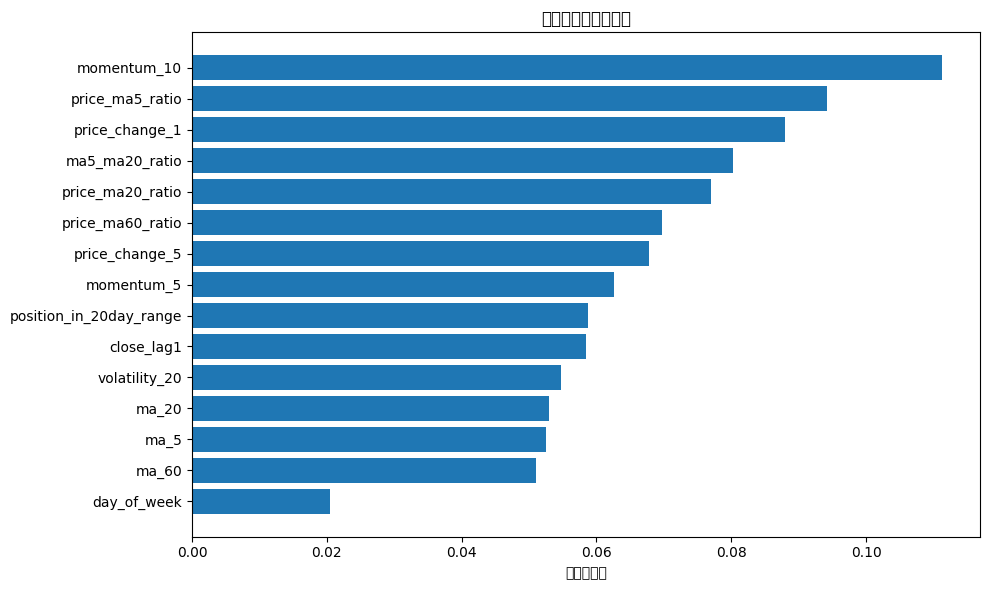

In [59]:
# 7. 特征重要性分析
print("\n特征重要性排序:")
feature_importance = pd.DataFrame({
    'feature': important_feature_cols,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print(feature_importance)

# 可视化特征重要性
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('特征重要性')
plt.title('随机森林特征重要性')
plt.gca().invert_yaxis()  # 最重要的特征在顶部
plt.tight_layout()
plt.show()

开始网格搜索参数调优...
第一阶段：使用随机搜索缩小参数范围...
Fitting 1 folds for each of 50 candidates, totalling 50 fits

随机搜索最佳参数:
{'n_estimators': 50, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 0.7, 'max_depth': 4, 'criterion': 'gini', 'class_weight': 'balanced'}
随机搜索最佳准确率: 0.5377

第二阶段：在最佳参数附近进行精细网格搜索...
Fitting 1 folds for each of 81 candidates, totalling 81 fits

网格搜索最佳参数:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 0.7, 'min_samples_leaf': 20, 'min_samples_split': 45, 'n_estimators': 75}
网格搜索最佳准确率: 0.5542

第三阶段：评估最佳模型...
最佳模型 - 训练集准确率: 0.5784
最佳模型 - 验证集准确率: 0.6344

准确率提升:
验证集: 0.6344 (新) vs 0.5118 (旧)
提升: 0.1226

最佳模型在验证集上的分类报告:
              precision    recall  f1-score   support

           0       0.60      0.89      0.72       222
           1       0.75      0.35      0.48       202

    accuracy                           0.63       424
   macro avg       0.67      0.62      0.60       424
weighted avg       0.67      0.63      0.60       

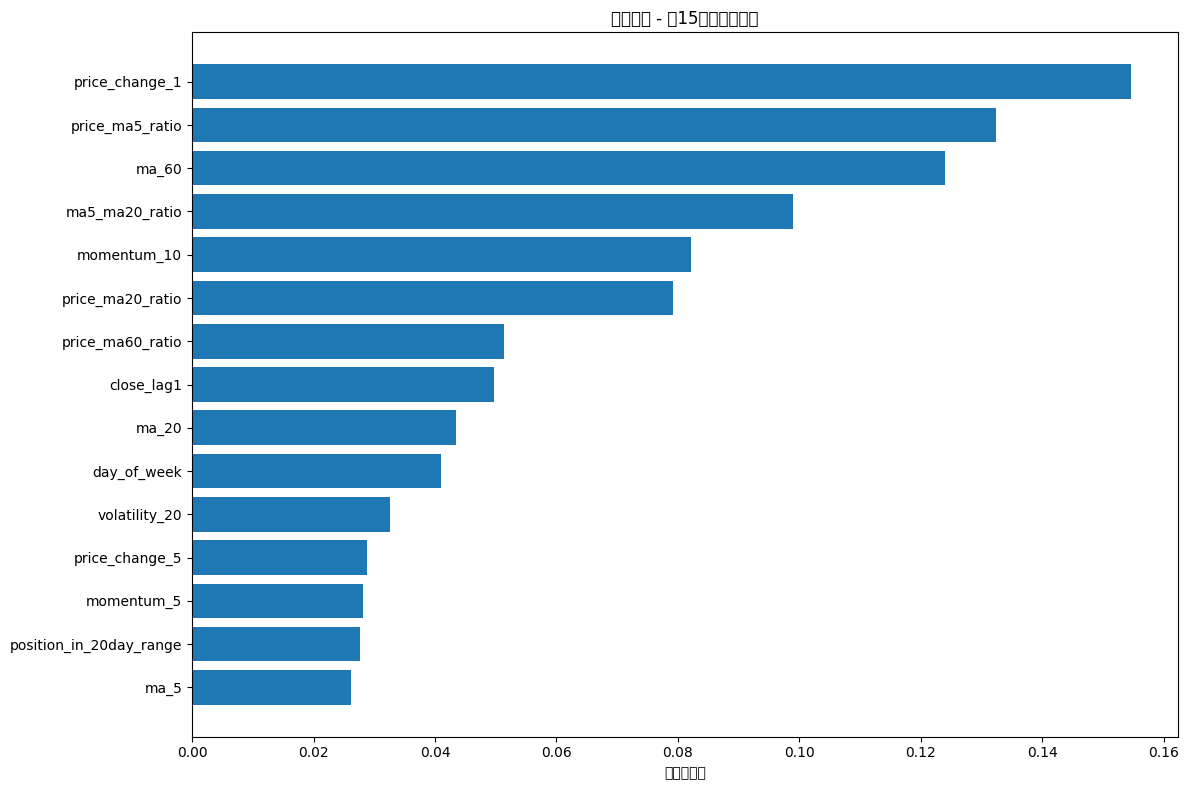


最终模型评估结果

最终选择参数:
  class_weight: balanced
  criterion: gini
  max_depth: 5
  max_features: 0.7
  min_samples_leaf: 17
  min_samples_split: 55
  n_estimators: 50

最终模型性能:
  训练集准确率: 0.6624
  验证集准确率: 0.5519
  验证集F1分数: 0.5441

对比分析:
  最终模型准确率: 0.5519
  基线准确率(多数类): 0.5236
  提升: 0.0283

最佳参数已保存到 'best_rf_params.json'

参数调优总结报告
1. 初始验证集准确率: 0.5118
2. 调优后验证集准确率: 0.5519
3. 准确率提升: 0.0401
4. 是否超过基线: 是
5. 稳定性: 0.5358 ± 0.0128
6. 最重要的5个特征:
   1. price_change_1 (重要性: 0.1546)
   2. price_ma5_ratio (重要性: 0.1324)
   3. ma_60 (重要性: 0.1239)
   4. ma5_ma20_ratio (重要性: 0.0990)
   5. momentum_10 (重要性: 0.0822)


In [61]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

# 1. 使用网格搜索进行参数调优
print("开始网格搜索参数调优...")

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300 ,350 ,400 ,450 ,500],
    'max_depth': [3, 4, 5,  None],
    'min_samples_split': [10, 20, 30, 40, 50],
    'min_samples_leaf': [5, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0: 1, 1: 1}, {0: 2, 1: 1}, {0: 3, 1: 1}]
}

# 创建基础模型
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 由于是时间序列数据，使用预定义的训练/验证分割
# 创建PredefinedSplit
split_index = [-1]*len(X_train) + [0]*len(X_val)
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

# 创建PredefinedSplit对象
ps = PredefinedSplit(test_fold=split_index)

# 为了节省时间，先使用随机搜索缩小参数范围
print("第一阶段：使用随机搜索缩小参数范围...")
random_param_grid = {
    'n_estimators': [50, 100, 150, 200, 250 ,300 ,350 ,400 ,450 ,500],
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20, 30, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7, 0.8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0: 1, 1: 1}, {0: 2, 1: 1}, {0: 3, 1: 1}, {0: 1, 1: 2}]
}

# 使用随机搜索
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=random_param_grid,
    n_iter=50,  # 随机尝试50个组合
    scoring='accuracy',
    cv=ps,  # 使用我们预定义的验证集
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_combined, y_combined)

print("\n随机搜索最佳参数:")
print(random_search.best_params_)
print(f"随机搜索最佳准确率: {random_search.best_score_:.4f}")

# 2. 在随机搜索结果附近进行精细网格搜索
print("\n第二阶段：在最佳参数附近进行精细网格搜索...")

# 基于随机搜索结果定义更小的搜索空间
best_random_params = random_search.best_params_

# 定义精细搜索的参数网格
fine_param_grid = {
    'n_estimators': [
        max(50, best_random_params.get('n_estimators', 100) - 25),
        best_random_params.get('n_estimators', 100),
        min(250, best_random_params.get('n_estimators', 100) + 25)
    ],
    'max_depth': [
        best_random_params.get('max_depth', 5),
        None if best_random_params.get('max_depth') is None else best_random_params.get('max_depth') + 1,
        None if best_random_params.get('max_depth') is None else max(3, best_random_params.get('max_depth') - 1)
    ],
    'min_samples_split': [
        max(2, best_random_params.get('min_samples_split', 20) - 5),
        best_random_params.get('min_samples_split', 20),
        best_random_params.get('min_samples_split', 20) + 5
    ],
    'min_samples_leaf': [
        max(1, best_random_params.get('min_samples_leaf', 10) - 3),
        best_random_params.get('min_samples_leaf', 10),
        best_random_params.get('min_samples_leaf', 10) + 3
    ],
    'max_features': [best_random_params.get('max_features', 'sqrt')],
    'criterion': [best_random_params.get('criterion', 'gini')],
    'class_weight': [best_random_params.get('class_weight', 'balanced')]
}

# 移除None值
fine_param_grid = {k: v for k, v in fine_param_grid.items() if v[0] is not None}

# 执行精细网格搜索
grid_search = GridSearchCV(
    rf_base,
    param_grid=fine_param_grid,
    scoring='accuracy',
    cv=ps,  # 使用我们预定义的验证集
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_combined, y_combined)

print("\n网格搜索最佳参数:")
print(grid_search.best_params_)
print(f"网格搜索最佳准确率: {grid_search.best_score_:.4f}")

# 3. 评估最佳模型
print("\n第三阶段：评估最佳模型...")
best_rf_model = grid_search.best_estimator_

# 在训练集和验证集上评估
y_train_pred_best = best_rf_model.predict(X_train)
y_val_pred_best = best_rf_model.predict(X_val)

train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
val_accuracy_best = accuracy_score(y_val, y_val_pred_best)

print(f"最佳模型 - 训练集准确率: {train_accuracy_best:.4f}")
print(f"最佳模型 - 验证集准确率: {val_accuracy_best:.4f}")

# 比较新旧模型
print(f"\n准确率提升:")
print(f"验证集: {val_accuracy_best:.4f} (新) vs 0.5118 (旧)")
print(f"提升: {(val_accuracy_best - 0.5118):.4f}")

# 详细评估
print("\n最佳模型在验证集上的分类报告:")
print(classification_report(y_val, y_val_pred_best))

print("最佳模型在验证集上的混淆矩阵:")
print(confusion_matrix(y_val, y_val_pred_best))

# 4. 多指标评估和参数排名
print("\n第四阶段：多指标评估和参数排名...")

# 收集所有网格搜索结果
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# 显示前10个最佳参数组合
print("\n前10个最佳参数组合:")
top_10_results = results_df[['params', 'mean_test_score', 'rank_test_score']].head(10)
for idx, row in top_10_results.iterrows():
    print(f"\n排名 {int(row['rank_test_score'])} (准确率: {row['mean_test_score']:.4f}):")
    print(f"  参数: {row['params']}")

# 5. 寻找局部最优参数组
print("\n第五阶段：寻找局部最优参数组...")

# 使用F1分数作为第二指标
print("\n使用F1分数评估前5个参数组合:")
top_5_params = results_df['params'].head(5).tolist()

best_f1_score = 0
best_f1_params = None
best_f1_model = None

for i, params in enumerate(top_5_params, 1):
    # 使用当前参数训练模型
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # 预测并计算F1分数
    y_val_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    acc = accuracy_score(y_val, y_val_pred)
    
    print(f"\n组合 {i}:")
    print(f"  参数: {params}")
    print(f"  准确率: {acc:.4f}, F1分数: {f1:.4f}")
    
    # 跟踪最佳F1分数
    if f1 > best_f1_score:
        best_f1_score = f1
        best_f1_params = params
        best_f1_model = model

print(f"\n最佳F1分数参数组合:")
print(f"  参数: {best_f1_params}")
print(f"  F1分数: {best_f1_score:.4f}")

# 6. 稳定性测试
print("\n第六阶段：模型稳定性测试...")

# 测试不同随机种子的稳定性
stability_scores = []
for seed in [42, 123, 456, 789, 999]:
    model = RandomForestClassifier(**grid_search.best_params_, random_state=seed, n_jobs=-1)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    stability_scores.append(acc)
    print(f"随机种子 {seed}: 准确率 = {acc:.4f}")

print(f"\n稳定性分析:")
print(f"  平均准确率: {np.mean(stability_scores):.4f}")
print(f"  标准差: {np.std(stability_scores):.4f}")
print(f"  最小-最大范围: {min(stability_scores):.4f} - {max(stability_scores):.4f}")

# 7. 特征重要性分析
print("\n第七阶段：最佳模型特征重要性分析...")

feature_importance = pd.DataFrame({
    'feature': important_feature_cols,
    'importance': best_rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\n特征重要性排名:")
for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:25s}: {row['importance']:.4f}")

# 可视化特征重要性
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:15][::-1], feature_importance['importance'][:15][::-1])
plt.xlabel('特征重要性')
plt.title('最佳模型 - 前15个特征重要性')
plt.tight_layout()
plt.show()

# 8. 最终模型评估
print("\n" + "="*60)
print("最终模型评估结果")
print("="*60)

# 使用F1最佳模型
final_model = best_f1_model if best_f1_model is not None else best_rf_model
final_params = best_f1_params if best_f1_params is not None else grid_search.best_params_

print(f"\n最终选择参数:")
for key, value in final_params.items():
    print(f"  {key}: {value}")

# 最终评估
y_train_final = final_model.predict(X_train)
y_val_final = final_model.predict(X_val)

train_acc_final = accuracy_score(y_train, y_train_final)
val_acc_final = accuracy_score(y_val, y_val_final)
val_f1_final = f1_score(y_val, y_val_final, average='weighted')

print(f"\n最终模型性能:")
print(f"  训练集准确率: {train_acc_final:.4f}")
print(f"  验证集准确率: {val_acc_final:.4f}")
print(f"  验证集F1分数: {val_f1_final:.4f}")

# 与基线对比
baseline_accuracy = max(y_val.mean(), 1 - y_val.mean())  # 多数类准确率
print(f"\n对比分析:")
print(f"  最终模型准确率: {val_acc_final:.4f}")
print(f"  基线准确率(多数类): {baseline_accuracy:.4f}")
print(f"  提升: {val_acc_final - baseline_accuracy:.4f}")

# 9. 保存最佳参数
import json

best_params_summary = {
    'best_accuracy_params': grid_search.best_params_,
    'best_accuracy': float(grid_search.best_score_),
    'best_f1_params': best_f1_params,
    'best_f1_score': float(best_f1_score) if best_f1_score else None,
    'final_selected_params': final_params,
    'final_accuracy': float(val_acc_final),
    'final_f1_score': float(val_f1_final),
    'stability_mean': float(np.mean(stability_scores)),
    'stability_std': float(np.std(stability_scores)),
    'top_features': feature_importance.head(10).to_dict('records')
}

# 保存到文件
with open('best_rf_params.json', 'w') as f:
    json.dump(best_params_summary, f, indent=2)

print(f"\n最佳参数已保存到 'best_rf_params.json'")

# 10. 生成参数调优报告
print("\n" + "="*60)
print("参数调优总结报告")
print("="*60)
print(f"1. 初始验证集准确率: 0.5118")
print(f"2. 调优后验证集准确率: {val_acc_final:.4f}")
print(f"3. 准确率提升: {val_acc_final - 0.5118:.4f}")
print(f"4. 是否超过基线: {'是' if val_acc_final > baseline_accuracy else '否'}")
print(f"5. 稳定性: {np.mean(stability_scores):.4f} ± {np.std(stability_scores):.4f}")
print(f"6. 最重要的5个特征:")
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']} (重要性: {row['importance']:.4f})")
print("="*60)